In [1]:
pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
df_session = pd.read_csv("sessions_kmeans_data(1).csv")

In [ ]:
df_session.shape

(400, 14)

In [ ]:
df_session.columns

Index(['session_id', 'user_id', 'username', 'time_spent', 'death_count',
       'max_checkpoint', 'completed', 'end_reason', 'map_id', 'created_at',
       'progress_score', 'survival_score', 'efficiency_score', 'skill_score'],
      dtype='object')

In [ ]:
df_session.head(400)

,session_id,user_id,username,time_spent,death_count,max_checkpoint,completed,end_reason,map_id,created_at,progress_score,survival_score,efficiency_score,skill_score
0,0d239753-102b-420c-ad70-00679793b4a2,USER_7,Player_7,159,7,3,False,exit,1,2026-03-01 12:43:32.311831,0.6,0.125000,1.000000,0.5775
1,b2b56a0d-3371-484b-9264-a4b15499d4cd,USER_45,Player_45,110,5,3,False,failed,1,2026-03-01 15:18:56.047858,0.6,0.166667,1.000000,0.5900
2,5c877d8e-5c56-49bd-8464-25ba0d41e283,USER_4,Player_4,234,22,2,False,exit,1,2026-03-01 17:12:17.293151,0.4,0.043478,1.000000,0.4730
3,19603833-d2d2-4523-9f02-b05d10d3d45f,USER_39,Player_39,299,4,4,False,exit,1,2026-03-01 19:18:56.178813,0.8,0.200000,1.000000,0.6800
4,56ab014c-5787-4d09-b585-e7c765b982d0,USER_6,Player_6,422,30,4,False,failed,1,2026-03-01 22:24:45.314478,0.8,0.032258,0.710900,0.5429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,1fdac793-301c-4e37-98fd-95a90b86d0a7,USER_14,Player_14,414,80,5,True,completed,1,2026-03-30 12:17:29.92976,1.0,0.012346,0.724638,0.6211
396,a214de8e-77a4-4652-8698-1d27cc20ac8b,USER_28,Player_28,494,1,4,False,failed,1,2026-03-30 19:01:04.727365,0.8,0.500000,0.607287,0.6522
397,e5e61a3f-36e4-47a1-9f34-f3464af0f234,USER_18,Player_18,132,19,2,False,exit,1,2026-03-30 21:27:45.274042,0.4,0.050000,1.000000,0.4750
398,c5eedc48-b524-4e3b-ae14-0415cee8a2e6,USER_37,Player_37,348,3,4,False,failed,1,2026-03-31 00:45:40.01359,0.8,0.250000,0.862069,0.6536


In [5]:
df_session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1954 entries, 0 to 1953
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   session_id         1954 non-null   object 
 1   user_id            1954 non-null   object 
 2   username           1954 non-null   object 
 3   time_spent         1954 non-null   int64  
 4   death_count        1954 non-null   int64  
 5   max_checkpoint     1954 non-null   int64  
 6   completed_numeric  1954 non-null   int64  
 7   completed          1954 non-null   bool   
 8   end_reason         1954 non-null   object 
 9   map_id             1954 non-null   int64  
 10  created_at         1954 non-null   object 
 11  efficiency_score   1954 non-null   float64
 12  survival_score     1954 non-null   float64
 13  progress_score     1954 non-null   float64
 14  skill_score        1954 non-null   float64
dtypes: bool(1), float64(4), int64(5), object(5)
memory usage: 215.8+ KB


In [6]:
df_session.isnull().sum()

,0
session_id,0
user_id,0
username,0
time_spent,0
death_count,0
max_checkpoint,0
completed_numeric,0
completed,0
end_reason,0
map_id,0


In [7]:
df_session["completed_numeric"] = df_session["completed"].astype(int)

df_session[["completed", "completed_numeric"]].head()

,completed,completed_numeric
0,True,1
1,False,0
2,False,0
3,False,0
4,False,0


In [8]:
session_features = [
    "time_spent",
    "death_count",
    "max_checkpoint",
    "completed_numeric",
    "progress_score",
    "survival_score",
    "efficiency_score",
    "skill_score"
]

X_session = df_session[session_features]

X_session.head(400)

,time_spent,death_count,max_checkpoint,completed_numeric,progress_score,survival_score,efficiency_score,skill_score
0,857,8,5,1,1.0,0.84,0.2858,0.7086
1,243,21,3,0,0.6,0.58,0.4785,0.5528
2,353,18,3,0,0.6,0.64,0.4235,0.5545
3,888,22,4,0,0.8,0.56,0.2080,0.5227
4,227,23,3,0,0.6,0.54,0.4865,0.5422
...,...,...,...,...,...,...,...,...
395,424,13,1,0,0.2,0.74,0.1293,0.3564
396,1092,34,3,0,0.6,0.32,0.0540,0.3247
397,957,10,2,0,0.4,0.80,0.0810,0.4270
398,699,2,2,0,0.4,0.96,0.1670,0.5090


In [9]:
X_session.describe()

,time_spent,death_count,max_checkpoint,completed_numeric,progress_score,survival_score,efficiency_score,skill_score
count,1954.000000,1954.000000,1954.000000,1954.000000,1954.000000,1954.000000,1954.000000,1954.000000
mean,426.479017,15.473900,3.067554,0.182702,0.613511,0.580985,0.489847,0.555795
std,259.872066,12.907826,1.386993,0.386521,0.277399,0.310071,0.300699,0.170374
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,230.000000,6.000000,2.000000,0.000000,0.400000,0.333333,0.231175,0.424850
50%,379.000000,12.000000,3.000000,0.000000,0.600000,0.660000,0.448850,0.553200
75%,563.750000,22.000000,4.000000,0.000000,0.800000,0.840000,0.719424,0.679776
max,1307.000000,80.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
from sklearn.preprocessing import StandardScaler

scaler_session = StandardScaler()
X_session_scaled = scaler_session.fit_transform(X_session)

X_session_scaled_df = pd.DataFrame(
    X_session_scaled,
    columns=session_features
)

X_session_scaled_df.head(10)

,time_spent,death_count,max_checkpoint,completed_numeric,progress_score,survival_score,efficiency_score,skill_score
0,1.657089,-0.579169,1.393620,2.115039,1.393620,0.835556,-0.678748,0.897111
1,-0.706217,0.428230,-0.048718,-0.472805,-0.048718,-0.003177,-0.037744,-0.017582
2,-0.282823,0.195753,-0.048718,-0.472805,-0.048718,0.190377,-0.220698,-0.007602
3,1.776409,0.505722,0.672451,-0.472805,0.672451,-0.067695,-0.937545,-0.194298
4,-0.767801,0.583214,-0.048718,-0.472805,-0.048718,-0.132213,-0.011133,-0.079814
5,-0.864027,-0.734153,-0.769886,-0.472805,-0.769886,0.964592,-0.522738,-0.106821
6,0.683284,-0.656661,-0.769886,-0.472805,-0.769886,0.900074,-0.968481,-0.408587
7,2.257538,0.428230,-0.769886,-0.472805,-0.769886,-0.003177,-1.422206,-1.223475
8,-0.875574,-0.734153,-1.491055,-0.472805,-1.491055,0.964592,-1.074594,-0.823076
9,0.617850,0.660706,1.393620,2.115039,1.393620,-0.196731,0.069700,0.711002


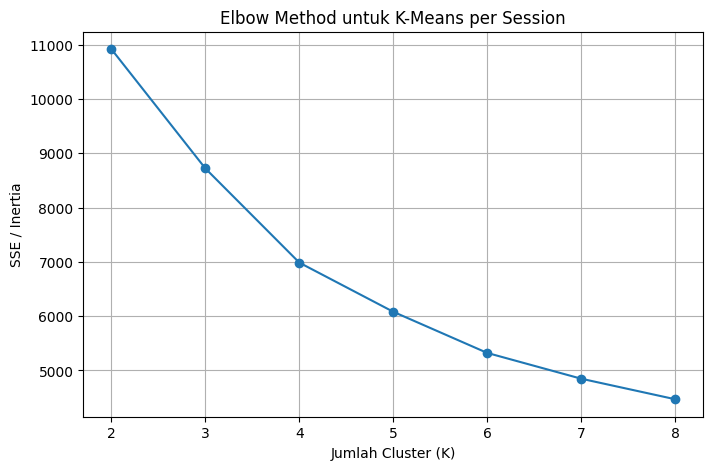

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse_session = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_session_scaled)
    sse_session.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, sse_session, marker="o")
plt.title("Elbow Method untuk K-Means per Session")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("SSE / Inertia")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

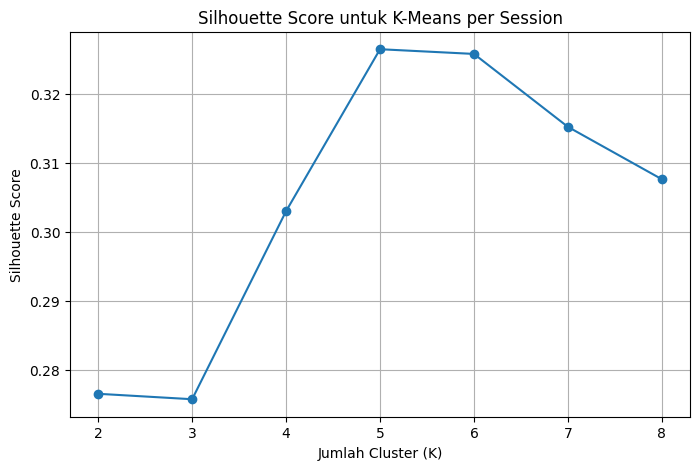

,K,SSE,Silhouette Score
0,2,10917.679095,0.276603
1,3,8720.732249,0.275818
2,4,6985.639424,0.303022
3,5,6080.487653,0.326438
4,6,5322.551096,0.325757
5,7,4847.810625,0.315210
6,8,4469.634435,0.307634


In [12]:
from sklearn.metrics import silhouette_score

silhouette_scores_session = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_session_scaled)
    score = silhouette_score(X_session_scaled, labels)
    silhouette_scores_session.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores_session, marker="o")
plt.title("Silhouette Score untuk K-Means per Session")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

eval_session_df = pd.DataFrame({
    "K": list(K_range),
    "SSE": sse_session,
    "Silhouette Score": silhouette_scores_session
})

eval_session_df

In [13]:
kmeans_session = KMeans(n_clusters=3, random_state=42, n_init=10)

df_session["session_cluster"] = kmeans_session.fit_predict(X_session_scaled)

df_session.head(400)

,session_id,user_id,username,time_spent,death_count,max_checkpoint,completed_numeric,completed,end_reason,map_id,created_at,efficiency_score,survival_score,progress_score,skill_score,session_cluster
0,a574d7e6-25a8-4f73-a146-46975068de94,USER_17,Player_17,857,8,5,1,True,summit,1,2025-01-01 21:26:56.301079,0.2858,0.84,1.0,0.7086,2
1,064ff446-e89d-47fa-ab44-3bf7411fe2c0,USER_12,Player_12,243,21,3,0,False,exit,1,2025-01-01 23:08:42.35288,0.4785,0.58,0.6,0.5528,0
2,4479cacb-6493-464c-a6dc-a733010b43df,USER_21,Player_21,353,18,3,0,False,exit,1,2025-01-02 00:44:27.09982,0.4235,0.64,0.6,0.5545,0
3,2d3b506a-75b7-47dc-bc6d-794a5a7ee7cb,USER_23,Player_23,888,22,4,0,False,exit,1,2025-01-04 02:21:30.013338,0.2080,0.56,0.8,0.5227,0
4,a962b8ee-cc15-4df5-8e2c-74ff155df16d,USER_20,Player_20,227,23,3,0,False,exit,1,2025-01-04 03:10:31.126145,0.4865,0.54,0.6,0.5422,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,96ffc9d8-6cb8-4bad-af56-4270253f336a,USER_46,Player_46,424,13,1,0,False,exit,1,2025-05-11 05:30:44.14921,0.1293,0.74,0.2,0.3564,1
396,e7848d0d-d9ae-4c34-876e-449e9a097497,USER_9,Player_9,1092,34,3,0,False,failed,1,2025-05-11 06:29:30.212963,0.0540,0.32,0.6,0.3247,1
397,a269b8d7-277e-4f2c-8579-d801b1c7f78a,USER_31,Player_31,957,10,2,0,False,unknown,1,2025-05-11 20:01:59.135963,0.0810,0.80,0.4,0.4270,1
398,34afc376-2d35-4b02-86cf-1fd7decfddbc,USER_37,Player_37,699,2,2,0,False,exit,1,2025-05-11 20:47:38.975349,0.1670,0.96,0.4,0.5090,1


In [14]:
df_session["session_cluster"].value_counts().sort_index()

,count
session_cluster,
0,876
1,721
2,357


In [15]:
session_cluster_summary = df_session.groupby("session_cluster")[session_features].mean().round(4)

session_cluster_summary["jumlah_session"] = df_session["session_cluster"].value_counts().sort_index()

session_cluster_summary

,time_spent,death_count,max_checkpoint,completed_numeric,progress_score,survival_score,efficiency_score,skill_score,jumlah_session
session_cluster,,,,,,,,,
0,388.0936,15.1792,3.5057,0.0,0.7011,0.5744,0.5711,0.6106,876
1,465.4632,15.5562,1.5811,0.0,0.3162,0.5993,0.3039,0.3914,721
2,441.9356,16.0308,4.9944,1.0,0.9989,0.5600,0.6660,0.7533,357


In [16]:
pd.crosstab(df_session["session_cluster"], df_session["completed"])

completed,False,True
session_cluster,,
0,876,0
1,721,0
2,0,357


In [17]:
pd.crosstab(
    df_session["session_cluster"],
    df_session["completed"],
    normalize="index"
).round(3) * 100

completed,False,True
session_cluster,,
0,100.0,0.0
1,100.0,0.0
2,0.0,100.0


In [18]:
pd.crosstab(df_session["session_cluster"], df_session["end_reason"])

end_reason,exit,failed,summit,unknown
session_cluster,,,,
0,639,207,0,30
1,508,158,0,55
2,0,0,357,0


In [19]:
pd.crosstab(
    df_session["session_cluster"],
    df_session["end_reason"],
    normalize="index"
).round(3) * 100

end_reason,exit,failed,summit,unknown
session_cluster,,,,
0,72.9,23.6,0.0,3.4
1,70.5,21.9,0.0,7.6
2,0.0,0.0,100.0,0.0


In [20]:
session_cluster_names = {
    0: "Sesi Sulit / Banyak Death",
    1: "Sesi Berhasil / Progres Maksimal",
    2: "Sesi Cepat namun Progress Rendah"
}

df_session["session_cluster_name"] = df_session["session_cluster"].map(session_cluster_names)

df_session[[
    "session_id",
    "user_id",
    "username",
    "time_spent",
    "death_count",
    "max_checkpoint",
    "completed",
    "end_reason",
    "progress_score",
    "survival_score",
    "efficiency_score",
    "skill_score",
    "session_cluster",
    "session_cluster_name"
]].head(20)

,session_id,user_id,username,time_spent,death_count,max_checkpoint,completed,end_reason,progress_score,survival_score,efficiency_score,skill_score,session_cluster,session_cluster_name
0,a574d7e6-25a8-4f73-a146-46975068de94,USER_17,Player_17,857,8,5,True,summit,1.0,0.84,0.2858,0.7086,2,Sesi Cepat namun Progress Rendah
1,064ff446-e89d-47fa-ab44-3bf7411fe2c0,USER_12,Player_12,243,21,3,False,exit,0.6,0.58,0.4785,0.5528,0,Sesi Sulit / Banyak Death
2,4479cacb-6493-464c-a6dc-a733010b43df,USER_21,Player_21,353,18,3,False,exit,0.6,0.64,0.4235,0.5545,0,Sesi Sulit / Banyak Death
3,2d3b506a-75b7-47dc-bc6d-794a5a7ee7cb,USER_23,Player_23,888,22,4,False,exit,0.8,0.56,0.2080,0.5227,0,Sesi Sulit / Banyak Death
4,a962b8ee-cc15-4df5-8e2c-74ff155df16d,USER_20,Player_20,227,23,3,False,exit,0.6,0.54,0.4865,0.5422,0,Sesi Sulit / Banyak Death
5,2d2b296e-b86c-40ad-9a4c-7023e2c65f85,USER_35,Player_35,202,6,2,False,exit,0.4,0.88,0.3327,0.5376,1,Sesi Berhasil / Progres Maksimal
6,94a95f37-73fe-4fb0-a1e0-a2406a5809f7,USER_24,Player_24,604,7,2,False,exit,0.4,0.86,0.1987,0.4862,1,Sesi Berhasil / Progres Maksimal
7,6256a06f-a245-41b2-9eb6-36200ff052d5,USER_23,Player_23,1013,21,2,False,unknown,0.4,0.58,0.0623,0.3474,1,Sesi Berhasil / Progres Maksimal
8,b70dd1f8-0938-4d65-9678-ec371d3cb7f3,USER_42,Player_42,199,6,1,False,exit,0.2,0.88,0.1668,0.4156,1,Sesi Berhasil / Progres Maksimal
9,796df4b7-4d38-47c2-bd06-a9b6218b4c18,USER_28,Player_28,587,24,5,True,summit,1.0,0.52,0.5108,0.6769,2,Sesi Cepat namun Progress Rendah


In [21]:
session_cluster_summary = df_session.groupby("session_cluster_name")[session_features].mean().round(4)
session_cluster_summary["jumlah_session"] = df_session["session_cluster_name"].value_counts()

session_cluster_summary

,time_spent,death_count,max_checkpoint,completed_numeric,progress_score,survival_score,efficiency_score,skill_score,jumlah_session
session_cluster_name,,,,,,,,,
Sesi Berhasil / Progres Maksimal,465.4632,15.5562,1.5811,0.0,0.3162,0.5993,0.3039,0.3914,721
Sesi Cepat namun Progress Rendah,441.9356,16.0308,4.9944,1.0,0.9989,0.5600,0.6660,0.7533,357
Sesi Sulit / Banyak Death,388.0936,15.1792,3.5057,0.0,0.7011,0.5744,0.5711,0.6106,876


In [22]:
pd.crosstab(df_session["session_cluster_name"], df_session["completed"])

completed,False,True
session_cluster_name,,
Sesi Berhasil / Progres Maksimal,721,0
Sesi Cepat namun Progress Rendah,0,357
Sesi Sulit / Banyak Death,876,0


In [23]:
pd.crosstab(df_session["session_cluster_name"], df_session["end_reason"])

end_reason,exit,failed,summit,unknown
session_cluster_name,,,,
Sesi Berhasil / Progres Maksimal,508,158,0,55
Sesi Cepat namun Progress Rendah,0,0,357,0
Sesi Sulit / Banyak Death,639,207,0,30


In [26]:
from sklearn.preprocessing import StandardScaler

features = [
    "time_spent",
    "death_count",
    "max_checkpoint",
    "completed_numeric",
    "efficiency_score",
    "survival_score",
    "progress_score",
    "skill_score"
]

X = df_session[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled berhasil dibuat")
print(X_scaled.shape)

X_scaled berhasil dibuat
(1954, 8)


In [29]:
df_session["completed_numeric"] = df_session["completed"].astype(int)

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df_session["pca_1"] = pca_result[:, 0]
df_session["pca_2"] = pca_result[:, 1]

df_session[["pca_1", "pca_2"]].head()

,pca_1,pca_2
0,2.388557,1.844880
1,-0.220131,-0.417709
2,-0.288045,0.036267
3,-0.057653,0.637288
4,-0.248477,-0.622886


In [31]:
session_result = df_session[[
    "session_id",
    "user_id",
    "username",
    "time_spent",
    "death_count",
    "max_checkpoint",
    "completed",
    "end_reason",
    "map_id",
    "created_at",
    "progress_score",
    "survival_score",
    "efficiency_score",
    "skill_score",
    "session_cluster",
    "session_cluster_name",
    "pca_1",
    "pca_2"
]]

session_result.to_csv("hasil_kmeans_session.csv", index=False)

session_result.head()

,session_id,user_id,username,time_spent,death_count,max_checkpoint,completed,end_reason,map_id,created_at,progress_score,survival_score,efficiency_score,skill_score,session_cluster,session_cluster_name,pca_1,pca_2
0,a574d7e6-25a8-4f73-a146-46975068de94,USER_17,Player_17,857,8,5,True,summit,1,2025-01-01 21:26:56.301079,1.0,0.84,0.2858,0.7086,2,Sesi Cepat namun Progress Rendah,2.388557,1.844880
1,064ff446-e89d-47fa-ab44-3bf7411fe2c0,USER_12,Player_12,243,21,3,False,exit,1,2025-01-01 23:08:42.35288,0.6,0.58,0.4785,0.5528,0,Sesi Sulit / Banyak Death,-0.220131,-0.417709
2,4479cacb-6493-464c-a6dc-a733010b43df,USER_21,Player_21,353,18,3,False,exit,1,2025-01-02 00:44:27.09982,0.6,0.64,0.4235,0.5545,0,Sesi Sulit / Banyak Death,-0.288045,0.036267
3,2d3b506a-75b7-47dc-bc6d-794a5a7ee7cb,USER_23,Player_23,888,22,4,False,exit,1,2025-01-04 02:21:30.013338,0.8,0.56,0.2080,0.5227,0,Sesi Sulit / Banyak Death,-0.057653,0.637288
4,a962b8ee-cc15-4df5-8e2c-74ff155df16d,USER_20,Player_20,227,23,3,False,exit,1,2025-01-04 03:10:31.126145,0.6,0.54,0.4865,0.5422,0,Sesi Sulit / Banyak Death,-0.248477,-0.622886


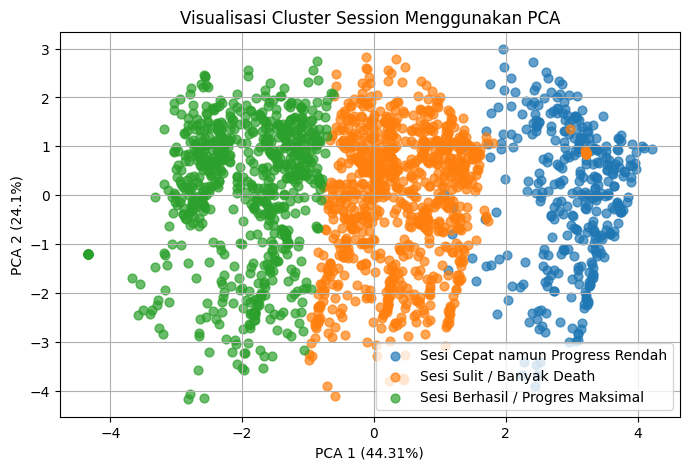

Explained variance PCA 1: 44.31 %
Explained variance PCA 2: 24.1 %
Total explained variance: 68.41 %


In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA 2D untuk visualisasi session cluster
pca_session = PCA(n_components=2)
X_session_pca = pca_session.fit_transform(X_session_scaled)

# Masukkan hasil PCA ke dataframe
df_session["pca_1"] = X_session_pca[:, 0]
df_session["pca_2"] = X_session_pca[:, 1]

# Hitung explained variance
pca1_var = round(pca_session.explained_variance_ratio_[0] * 100, 2)
pca2_var = round(pca_session.explained_variance_ratio_[1] * 100, 2)
total_var = round(sum(pca_session.explained_variance_ratio_) * 100, 2)

# Visualisasi PCA
plt.figure(figsize=(8, 5))

for cluster_name in df_session["session_cluster_name"].unique():
    subset = df_session[df_session["session_cluster_name"] == cluster_name]
    plt.scatter(
        subset["pca_1"],
        subset["pca_2"],
        label=cluster_name,
        s=40,
        alpha=0.7
    )

plt.title("Visualisasi Cluster Session Menggunakan PCA")
plt.xlabel(f"PCA 1 ({pca1_var}%)")
plt.ylabel(f"PCA 2 ({pca2_var}%)")
plt.legend()
plt.grid(True)
plt.show()

print("Explained variance PCA 1:", pca1_var, "%")
print("Explained variance PCA 2:", pca2_var, "%")
print("Total explained variance:", total_var, "%")

In [35]:
# Simpan ke CSV
session_result.to_csv("hasil_kmeans_session.csv", index=False)

print("Hasil K-Means Session berhasil disimpan!")
print("Nama file: hasil_kmeans_session.csv")
print("Jumlah baris:", len(session_result))
display(session_result.head())

Hasil K-Means Session berhasil disimpan!
Nama file: hasil_kmeans_session.csv
Jumlah baris: 1954


,session_id,user_id,username,time_spent,death_count,max_checkpoint,completed,end_reason,map_id,created_at,progress_score,survival_score,efficiency_score,skill_score,session_cluster,session_cluster_name,pca_1,pca_2
0,a574d7e6-25a8-4f73-a146-46975068de94,USER_17,Player_17,857,8,5,True,summit,1,2025-01-01 21:26:56.301079,1.0,0.84,0.2858,0.7086,2,Sesi Cepat namun Progress Rendah,2.388557,1.844880
1,064ff446-e89d-47fa-ab44-3bf7411fe2c0,USER_12,Player_12,243,21,3,False,exit,1,2025-01-01 23:08:42.35288,0.6,0.58,0.4785,0.5528,0,Sesi Sulit / Banyak Death,-0.220131,-0.417709
2,4479cacb-6493-464c-a6dc-a733010b43df,USER_21,Player_21,353,18,3,False,exit,1,2025-01-02 00:44:27.09982,0.6,0.64,0.4235,0.5545,0,Sesi Sulit / Banyak Death,-0.288045,0.036267
3,2d3b506a-75b7-47dc-bc6d-794a5a7ee7cb,USER_23,Player_23,888,22,4,False,exit,1,2025-01-04 02:21:30.013338,0.8,0.56,0.2080,0.5227,0,Sesi Sulit / Banyak Death,-0.057653,0.637288
4,a962b8ee-cc15-4df5-8e2c-74ff155df16d,USER_20,Player_20,227,23,3,False,exit,1,2025-01-04 03:10:31.126145,0.6,0.54,0.4865,0.5422,0,Sesi Sulit / Banyak Death,-0.248477,-0.622886
